In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

import mediapipe as mp

In [195]:
from mediapipe.tasks.python.vision import (
    drawing_utils, drawing_styles,
    HandLandmarker, HandLandmarksConnections, HandLandmarkerOptions,
    ImageSegmenter, ImageSegmenterOptions,
    GestureRecognizerOptions, GestureRecognizer,
    FaceDetectorOptions, FaceDetector,
    FaceLandmarkerOptions, FaceLandmarker, FaceLandmarksConnections
)

In [3]:
MODEL_DIR = '../models'
os.makedirs(MODEL_DIR, exist_ok=True)


In [10]:
from urllib.request import urlretrieve
from urllib.parse import urlparse

def get_model(url):
    filename = os.path.basename(urlparse(url).path)
    path = os.path.join(MODEL_DIR, filename)

    if not os.path.exists(path):
        urlretrieve(url, path)
        print(f"Model {filename} downloaded")
    
    return path

# Hand Tracking

In [112]:
def hand_result(image: mp.Image, results):
    rgb_image = image.numpy_view()
    hand_landmarks_list = results.hand_landmarks
    annotated_image = np.copy(rgb_image)

    for hand_landmarks in hand_landmarks_list:
        drawing_utils.draw_landmarks(
            annotated_image,
            hand_landmarks,
            HandLandmarksConnections.HAND_CONNECTIONS,
            drawing_utils.DrawingSpec(color=(0, 255, 0), thickness=2, circle_radius=2),
            drawing_utils.DrawingSpec(color=(0, 0, 255), thickness=2),
        )

    plt.imshow(annotated_image)
    plt.axis("off")
    plt.show()

In [11]:
model_url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task"
model_path = get_model(model_url)

In [12]:
hand_opt = HandLandmarkerOptions(
    base_options=mp.tasks.BaseOptions(model_asset_path=model_path),
    num_hands=2,
    min_hand_detection_confidence=0.6,
    min_hand_presence_confidence=0.6,
    min_tracking_confidence=0.6
)
hand_detector = HandLandmarker.create_from_options(hand_opt)

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1786416377.329339   34574 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786416377.342084   34573 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [13]:
hand_path = get_model("https://storage.googleapis.com/mediapipe-tasks/hand_landmarker/woman_hands.jpg")
hand_path

Model woman_hands.jpg downloaded


'../models/woman_hands.jpg'

In [15]:
image = mp.Image.create_from_file(hand_path)
result = hand_detector.detect(image)

W0000 00:00:1786416694.640421   35523 landmark_projection_calculator.cc:81] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


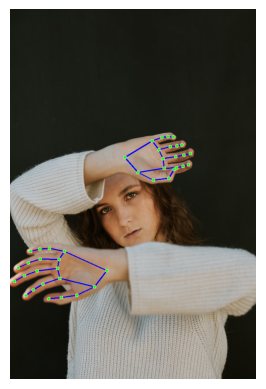

In [ ]:
hand_result(image, result)

In [ ]:
rgb_image = image.numpy_view()
rgb_image[0]

array([[[21, 24, 17],
        [21, 24, 17],
        [21, 24, 17],
        ...,
        [23, 24, 16],
        [23, 24, 16],
        [23, 24, 16]],

       [[21, 24, 17],
        [21, 24, 17],
        [21, 24, 17],
        ...,
        [23, 24, 16],
        [23, 24, 16],
        [23, 24, 16]],

       [[21, 24, 17],
        [21, 24, 17],
        [21, 24, 17],
        ...,
        [23, 24, 16],
        [23, 24, 16],
        [23, 24, 16]],

       ...,

       [[15, 16, 10],
        [15, 16, 10],
        [15, 16, 10],
        ...,
        [16, 16,  8],
        [16, 16,  8],
        [16, 16,  8]],

       [[15, 16, 10],
        [15, 16, 10],
        [15, 16, 10],
        ...,
        [15, 15,  7],
        [16, 16,  8],
        [16, 16,  8]],

       [[15, 16, 10],
        [15, 16, 10],
        [15, 16, 10],
        ...,
        [15, 15,  7],
        [15, 15,  7],
        [15, 15,  7]]], shape=(960, 640, 3), dtype=uint8)

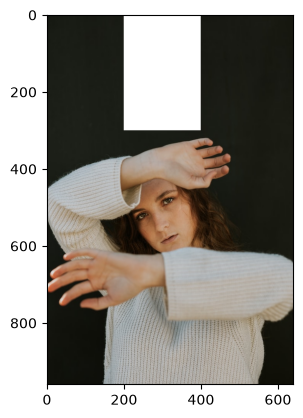

In [53]:
img = np.copy(rgb_image)

img[:300, 200:400] = [255, 255, 255]
plt.imshow(img)

In [18]:
result.handedness

[[Category(index=1, score=0.9357723593711853, display_name='Left', category_name='Left')],
 [Category(index=0, score=0.960904598236084, display_name='Right', category_name='Right')]]

In [22]:
result.hand_landmarks

[[NormalizedLandmark(x=0.3929191529750824, y=0.7066094875335693, z=-3.2930338988990115e-07, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.34312066435813904, y=0.7504479289054871, z=-0.019821524620056152, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.2708950936794281, y=0.7737333178520203, z=-0.02736593224108219, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.20807711780071259, y=0.7796701192855835, z=-0.036947112530469894, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.1570494920015335, y=0.782977283000946, z=-0.045807499438524246, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.20208579301834106, y=0.7279683351516724, z=0.004851881414651871, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.132952481508255, y=0.7431298494338989, z=-0.018509216606616974, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.09457838535308838, y=0.7587482333183

In [28]:
result.hand_world_landmarks

[[Landmark(x=0.08694982528686523, y=0.014125330373644829, z=-0.03094503842294216, visibility=None, presence=None, name=None),
  Landmark(x=0.06219656765460968, y=0.03361155092716217, z=-0.024820204824209213, visibility=None, presence=None, name=None),
  Landmark(x=0.039285942912101746, y=0.042401283979415894, z=-0.015132742933928967, visibility=None, presence=None, name=None),
  Landmark(x=0.00451410748064518, y=0.05077169090509415, z=-0.0006790379993617535, visibility=None, presence=None, name=None),
  Landmark(x=-0.025179531425237656, y=0.05264487490057945, z=0.015766825526952744, visibility=None, presence=None, name=None),
  Landmark(x=0.0011319974437355995, y=0.022390294820070267, z=0.013610733672976494, visibility=None, presence=None, name=None),
  Landmark(x=-0.027234064415097237, y=0.026896383613348007, z=0.006937531754374504, visibility=None, presence=None, name=None),
  Landmark(x=-0.04652116447687149, y=0.036523185670375824, z=-0.0036683224607259035, visibility=None, presence

# Image Segmentation

In [54]:
seg_url = 'https://storage.googleapis.com/mediapipe-models/image_segmenter/deeplab_v3/float32/1/deeplab_v3.tflite'
seg_img = 'https://storage.googleapis.com/mediapipe-assets/segmentation_input_rotation0.jpg'
seg_path = get_model(seg_url)
seg_img = get_model(seg_img)

Model deeplab_v3.tflite downloaded
Model segmentation_input_rotation0.jpg downloaded


In [58]:
seg_opt = ImageSegmenterOptions(
    base_options=mp.tasks.BaseOptions(model_asset_path=seg_path),
    output_category_mask=True
)
segmenter = ImageSegmenter.create_from_options(seg_opt)

W0000 00:00:1786423500.828084   66697 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [65]:
image = mp.Image.create_from_file(seg_img)
result = segmenter.segment(image)

In [102]:
def mask_result(image: mp.Image, result):
    mask = result.category_mask.numpy_view()
    conditions = mask.squeeze() > 0
    image_rgb = np.copy(image.numpy_view())
    fg_image = np.zeros(image_rgb.shape, np.uint8)
    fg_image[:] = image_rgb
    image_rgb[:] = (192, 192, 192)

    output_img = np.where(conditions[..., None], fg_image, image_rgb)

    plt.imshow(output_img)
    plt.axis("off")
    plt.show()

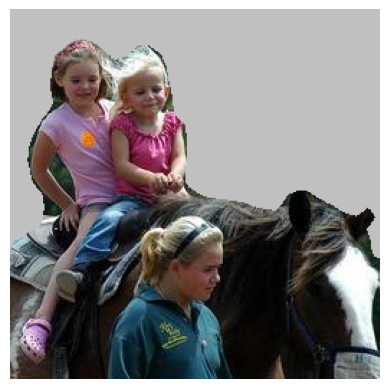

In [103]:
mask_result(image, result)

# Gesture Recognizer

In [104]:
gesture_url = 'https://storage.googleapis.com/mediapipe-models/gesture_recognizer/gesture_recognizer/float16/1/gesture_recognizer.task'
IMAGE_FILENAMES = ['thumbs_down.jpg', 'victory.jpg', 'thumbs_up.jpg', 'pointing_up.jpg']

gesture_model = get_model(gesture_url)
for name in IMAGE_FILENAMES:
  url = f'https://storage.googleapis.com/mediapipe-tasks/gesture_recognizer/{name}'
  get_model(url)

Model gesture_recognizer.task downloaded
Model thumbs_down.jpg downloaded
Model victory.jpg downloaded
Model thumbs_up.jpg downloaded
Model pointing_up.jpg downloaded


In [106]:
rec_opt = GestureRecognizerOptions(
    base_options=mp.tasks.BaseOptions(model_asset_path=gesture_model)
)
recognizer = GestureRecognizer.create_from_options(rec_opt)

I0000 00:00:1786435159.498326  100014 hand_gesture_recognizer_graph.cc:257] Custom gesture classifier is not defined.
W0000 00:00:1786435159.527934  100018 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786435159.539520  100018 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786435159.540943  100018 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786435159.541086  100018 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [117]:
img_path = f"../models/{IMAGE_FILENAMES[1]}"
image = mp.Image.create_from_file(img_path)
result = recognizer.recognize(image)

Gesture Classification

- 0 - Unrecognized gesture, label: Unknown
- 1 - Closed fist, label: Closed_Fist
- 2 - Open palm, label: Open_Palm
- 3 - Pointing up, label: Pointing_Up
- 4 - Thumbs down, label: Thumb_Down
- 5 - Thumbs up, label: Thumb_Up
- 6 - Victory, label: Victory
- 7 - Love, label: ILoveYou

In [118]:
result.gestures

[[Category(index=-1, score=0.9083037972450256, display_name=None, category_name='Victory')]]

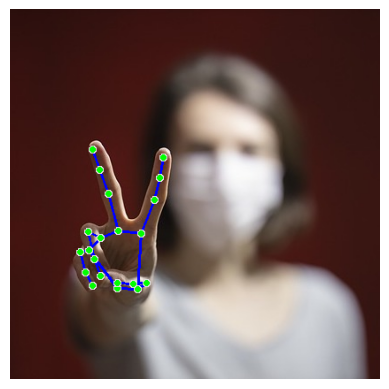

In [119]:
hand_result(image, result)

# Face Recognition

In [172]:
face_url = 'https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_full_range/float16/latest/blaze_face_full_range.tflite'
face_model = get_model(face_url)
face_img = get_model('https://img.magnific.com/free-photo/beautiful-sensual-woman-touching-her-face-isolated-white-wall-beauty-skincare-concept-spa_231208-1460.jpg?semt=ais_test_b&w=740&q=80')

Model beautiful-sensual-woman-touching-her-face-isolated-white-wall-beauty-skincare-concept-spa_231208-1460.jpg downloaded


In [173]:
face_opt = FaceDetectorOptions(
    base_options=mp.tasks.BaseOptions(model_asset_path=face_model)
)
face_detector = FaceDetector.create_from_options(face_opt)

W0000 00:00:1786440885.591542  110900 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [174]:
image = mp.Image.create_from_file(face_img)
result = face_detector.detect(image)

In [175]:
image.numpy_view().shape

(493, 740, 3)

In [176]:
len(result.detections)

1

In [177]:
result.detections[0].bounding_box

BoundingBox(origin_x=253, origin_y=172, width=196, height=196)

In [178]:
result.detections[0].categories

[Category(index=0, score=0.8107819557189941, display_name=None, category_name=None)]

In [179]:
result.detections[0].keypoints

[NormalizedKeypoint(x=0.423174113035202, y=0.537656307220459, label=None, score=0.0),
 NormalizedKeypoint(x=0.5061967372894287, y=0.4697907865047455, label=None, score=0.0),
 NormalizedKeypoint(x=0.4615101218223572, y=0.6133495569229126, label=None, score=0.0),
 NormalizedKeypoint(x=0.5005261898040771, y=0.6673382520675659, label=None, score=0.0),
 NormalizedKeypoint(x=0.44321364164352417, y=0.5612505674362183, label=None, score=0.0),
 NormalizedKeypoint(x=0.6277822852134705, y=0.41704991459846497, label=None, score=0.0)]

In [180]:
import math

def _normalized_to_pixel_coordinates(normalized_x: float, normalized_y: float, image_width: int, image_height: int):
    """Converts normalized value pair to pixel coordinates."""

    # Checks if the float value is between 0 and 1.
    def is_valid_normalized_value(value: float) -> bool:
        return (value > 0 or math.isclose(0, value)) and (value < 1 or math.isclose(1, value))

    if not (is_valid_normalized_value(normalized_x) and is_valid_normalized_value(normalized_y)):
        # TODO: Draw coordinates even if it's outside of the image bounds.
        return None
    
    x_px = min(math.floor(normalized_x * image_width), image_width - 1)
    y_px = min(math.floor(normalized_y * image_height), image_height - 1)
    return x_px, y_px

def face_result(image: mp.Image, result):
    annotated_image = image.numpy_view().copy()
    h, w, _ = annotated_image.shape

    for detection in result.detections:
        bbox = detection.bounding_box
        start_point = (bbox.origin_x, bbox.origin_y)
        end_point = (bbox.origin_x + bbox.width, bbox.origin_y + bbox.height)
        cv2.rectangle(annotated_image, start_point, end_point, (255, 0, 0), 2)

        for keypoint in detection.keypoints:
            # kp = _normalized_to_pixel_coordinates(keypoint.x, keypoint.y, w, h)
            kp = int(keypoint.x * w), int(keypoint.y * h)

            color, thickness, radius = (0, 255, 0), 2, 2
            cv2.circle(annotated_image, kp, thickness, color, radius)

    plt.imshow(annotated_image)
    plt.axis("off")
    plt.show()

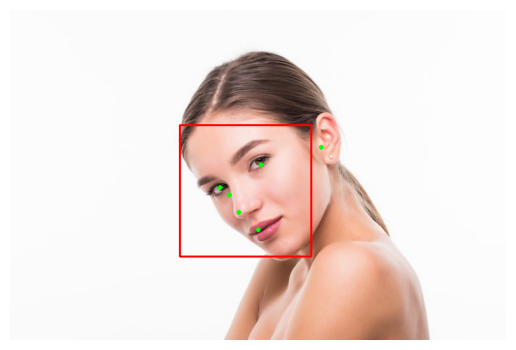

In [181]:
face_result(image, result)

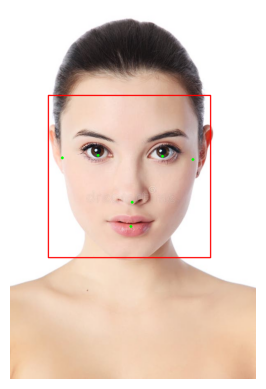

In [162]:
face_result(image, result)

# Face Landmark

In [184]:
face_lm_url = 'https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task'

face_lm_model = get_model(face_lm_url)
face_img = get_model('https://storage.googleapis.com/mediapipe-assets/business-person.png')

Model face_landmarker.task downloaded


In [198]:
face_lm_opt = FaceLandmarkerOptions(
    base_options=mp.tasks.BaseOptions(model_asset_path=face_lm_model),
    output_face_blendshapes=True,
    output_facial_transformation_matrixes=True
)
face_lm = FaceLandmarker.create_from_options(face_lm_opt)

W0000 00:00:1786442310.056701  113159 face_landmarker_graph.cc:180] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
W0000 00:00:1786442310.062024  113162 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1786442310.074673  113162 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [199]:
image = mp.Image.create_from_file(face_img)
result = face_lm.detect(image)

In [200]:
result.face_blendshapes

[[Category(index=0, score=2.7256046450929716e-06, display_name=None, category_name='_neutral'),
  Category(index=1, score=0.12565810978412628, display_name=None, category_name='browDownLeft'),
  Category(index=2, score=0.10740809887647629, display_name=None, category_name='browDownRight'),
  Category(index=3, score=0.00015085467020981014, display_name=None, category_name='browInnerUp'),
  Category(index=4, score=0.05805644765496254, display_name=None, category_name='browOuterUpLeft'),
  Category(index=5, score=0.029607193544507027, display_name=None, category_name='browOuterUpRight'),
  Category(index=6, score=3.763317727134563e-05, display_name=None, category_name='cheekPuff'),
  Category(index=7, score=2.0549529722302395e-07, display_name=None, category_name='cheekSquintLeft'),
  Category(index=8, score=2.6737100711216044e-07, display_name=None, category_name='cheekSquintRight'),
  Category(index=9, score=0.06273426115512848, display_name=None, category_name='eyeBlinkLeft'),
  Catego

In [201]:
len(result.face_landmarks[0])

478

In [202]:
result.face_landmarks

[[NormalizedLandmark(x=0.5364489555358887, y=0.27763405442237854, z=-0.022393720224499702, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.5379412770271301, y=0.2537103593349457, z=-0.06188183277845383, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.5362502932548523, y=0.25981900095939636, z=-0.028650453314185143, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.5250511169433594, y=0.2257542908191681, z=-0.05379120633006096, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.537519097328186, y=0.24548965692520142, z=-0.06760260462760925, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.5360761880874634, y=0.23402778804302216, z=-0.06552405655384064, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.5319814085960388, y=0.20557688176631927, z=-0.04197018966078758, visibility=None, presence=None, name=None),
  NormalizedLandmark(x=0.4447021484375, y=0.2013048231601715, z

In [203]:
result.facial_transformation_matrixes

[array([[ 9.9221164e-01, -6.0493961e-02,  1.0888966e-01,  1.1876172e+00],
        [ 9.1041707e-02,  9.4880110e-01, -3.0247039e-01,  2.2372719e+01],
        [-8.5016973e-02,  3.1002823e-01,  9.4691873e-01, -6.8015282e+01],
        [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  1.0000000e+00]],
       dtype=float32)]

In [ ]:
def face_lm_result(image: mp.Image, result):
    annotated_image = image.numpy_view().copy()

    for landmarks in result.face_landmarks:
        drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=landmarks,
            connections=FaceLandmarksConnections.FACE_LANDMARKS_TESSELATION,
            landmark_drawing_spec=None,
            connection_drawing_spec=drawing_styles.get_default_face_mesh_tesselation_style()
        )
        drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=landmarks,
            connections=FaceLandmarksConnections.FACE_LANDMARKS_CONTOURS,
            landmark_drawing_spec=None,
            connection_drawing_spec=drawing_styles.get_default_face_mesh_contours_style()
        )
        drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=landmarks,
            connections=FaceLandmarksConnections.FACE_LANDMARKS_LEFT_IRIS,
            landmark_drawing_spec=None,
            connection_drawing_spec=drawing_styles.get_default_face_mesh_iris_connections_style()
        )
        drawing_utils.draw_landmarks(
            image=annotated_image,
            landmark_list=landmarks,
            connections=FaceLandmarksConnections.FACE_LANDMARKS_RIGHT_IRIS,
            landmark_drawing_spec=None,
            connection_drawing_spec=drawing_styles.get_default_face_mesh_iris_connections_style()
        )

    plt.imshow(annotated_image)
    plt.axis("off")
    plt.show()

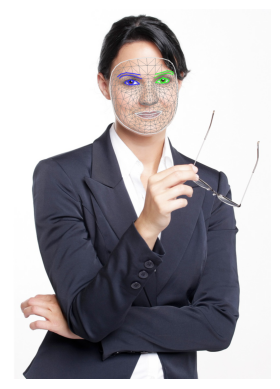

In [197]:
face_lm_result(image, result)

In [204]:
def plot_face_blendshapes_bar_graph(face_blendshapes):
    # Extract the face blendshapes category names and scores.
    face_blendshapes_names = [face_blendshapes_category.category_name for face_blendshapes_category in face_blendshapes]
    face_blendshapes_scores = [face_blendshapes_category.score for face_blendshapes_category in face_blendshapes]
    # The blendshapes are ordered in decreasing score value.
    face_blendshapes_ranks = range(len(face_blendshapes_names))

    _, ax = plt.subplots(figsize=(12, 12))
    bar = ax.barh(face_blendshapes_ranks, face_blendshapes_scores, label=[str(x) for x in face_blendshapes_ranks])
    ax.set_yticks(face_blendshapes_ranks, face_blendshapes_names)
    ax.invert_yaxis()

    # Label each bar with values
    for score, patch in zip(face_blendshapes_scores, bar.patches):
        plt.text(patch.get_x() + patch.get_width(), patch.get_y(), f"{score:.4f}", va="top")

    ax.set_xlabel('Score')
    ax.set_title("Face Blendshapes")
    plt.tight_layout()
    plt.show()

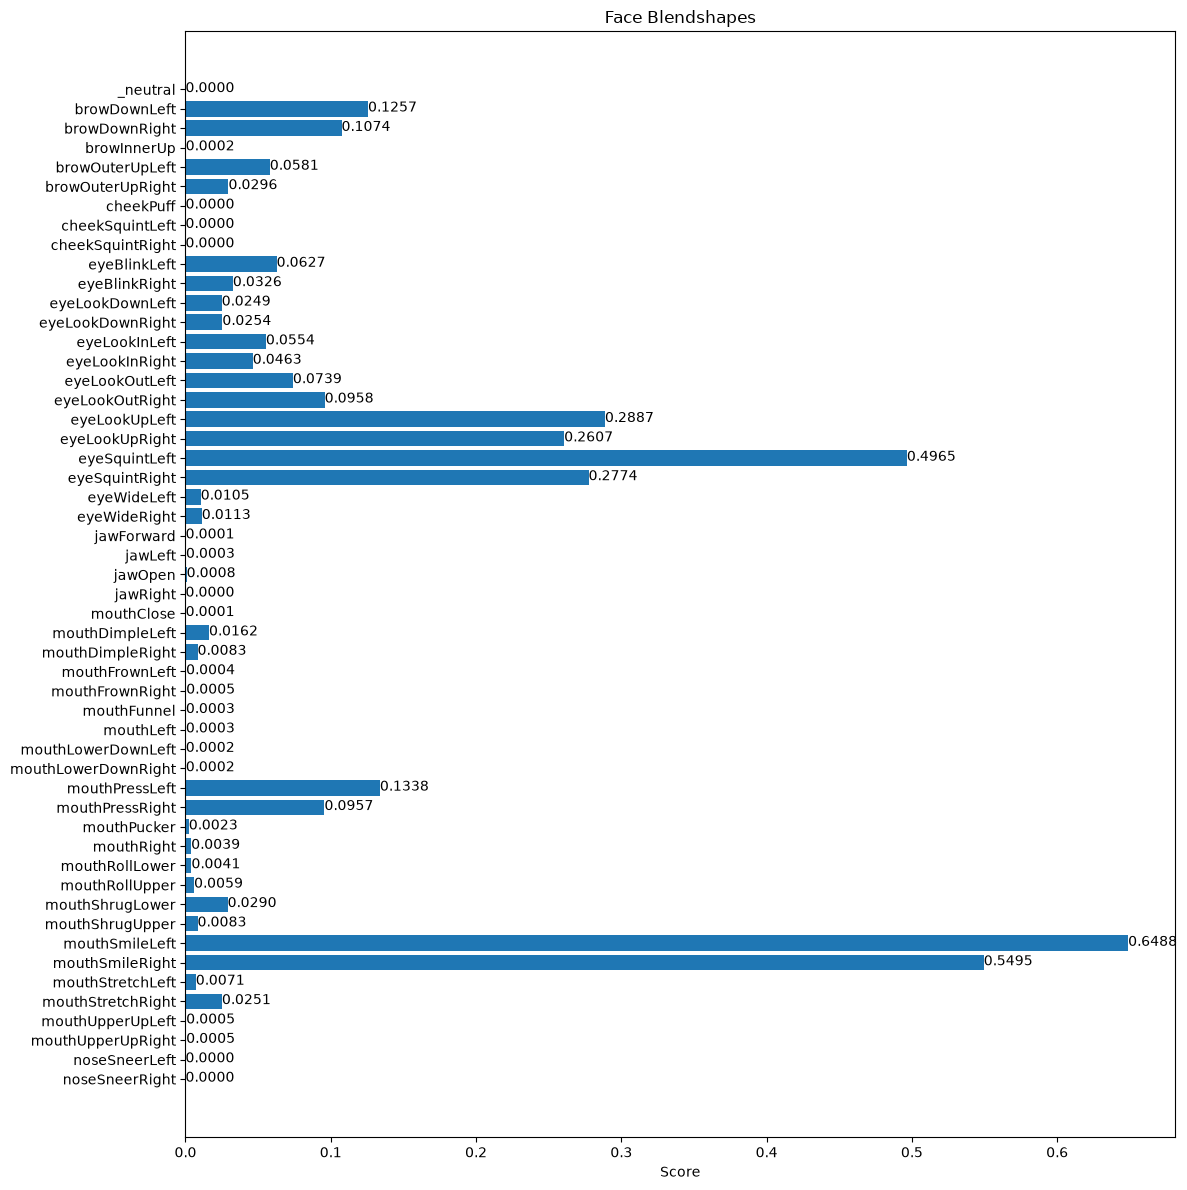

In [205]:
plot_face_blendshapes_bar_graph(result.face_blendshapes[0])